In [1]:
import os
import csv
import json
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
os.makedirs("./artifacts/figures", exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

RANDOM_SEED = 42
seed_everything(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
df = pd.read_csv("./data/S12-hw-dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Размер: {df.shape}")
print(f"Диапазон: {df['date'].min()} - {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")

Размер: (4320, 2)
Диапазон: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64


In [4]:
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [5]:
df.describe()

,date,target
count,4320,4320.000000
mean,2025-03-31 23:29:59.999999744,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4320 non-null   datetime64[ns]
 1   target  4320 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 67.6 KB


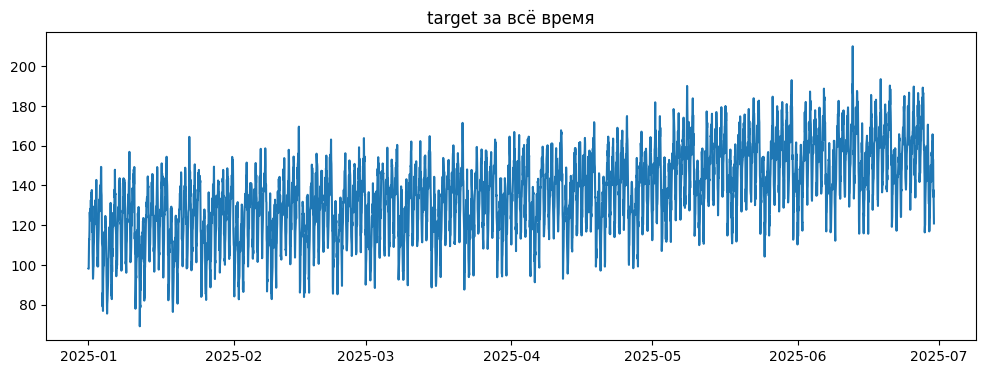

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['target'])
plt.title("target за всё время")
plt.show()

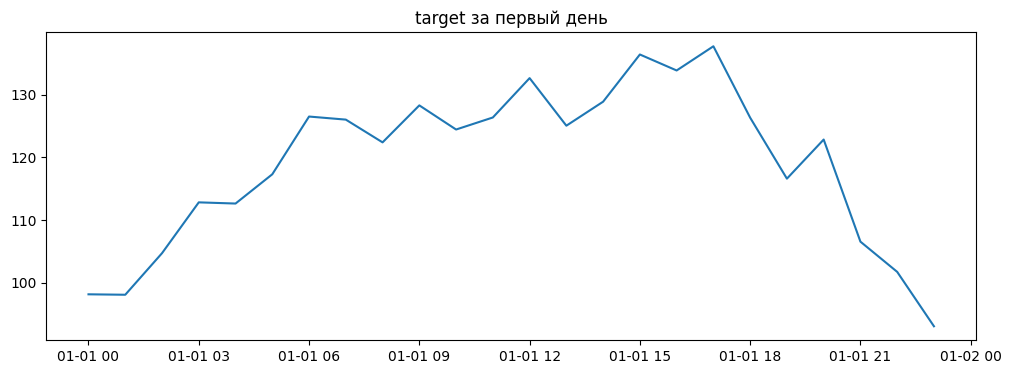

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[:24, :]['date'], df.iloc[:24, :]['target'])
plt.title("target за первый день")
plt.show()

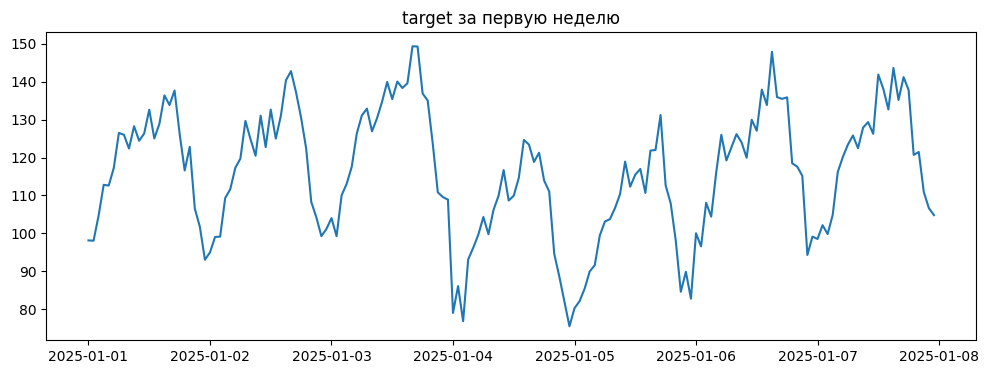

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[:24*7, :]['date'], df.iloc[:24*7, :]['target'])
plt.title("target за первую неделю")
plt.show()

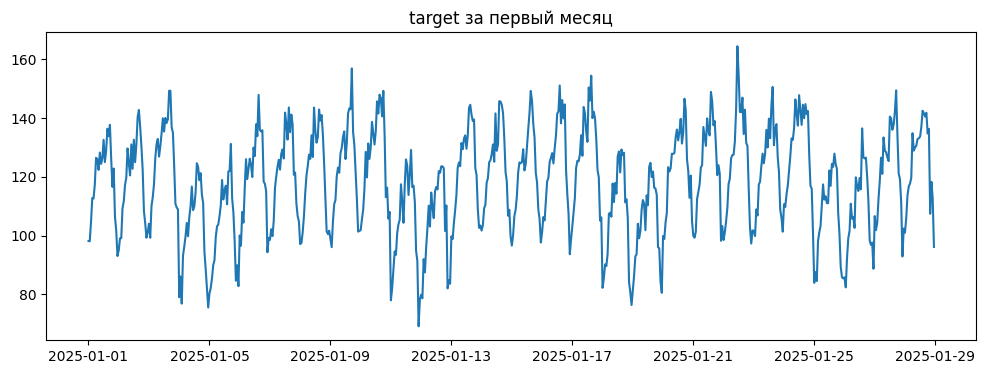

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[:24*7*4, :]['date'], df.iloc[:24*7*4, :]['target'])
plt.title("target за первый месяц")
plt.show()

В датасете лежат данные в виде временного ряда за первое полугодие 2025 года (с 1 января по 29 июня включительно). Замер целевой переменной `target` происходил каждый час. Есть слабый ростущий тренд + сильно выраженная сезонность внутри дня (поднимается в пик днеём и падает ночью) и внутринедельная (по выходным заметно ниже). 
Пропусков нет

In [11]:
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

Важно, что вместо классического `random split`, который перемешивает все наблюдения в хаотичном порядке, нужно выполнить `temporal split` - разбиение с сохранением закономерности данных во временной последовательности. В данном случае я выберу 70% на обучение, 15 на тест и валидацию.

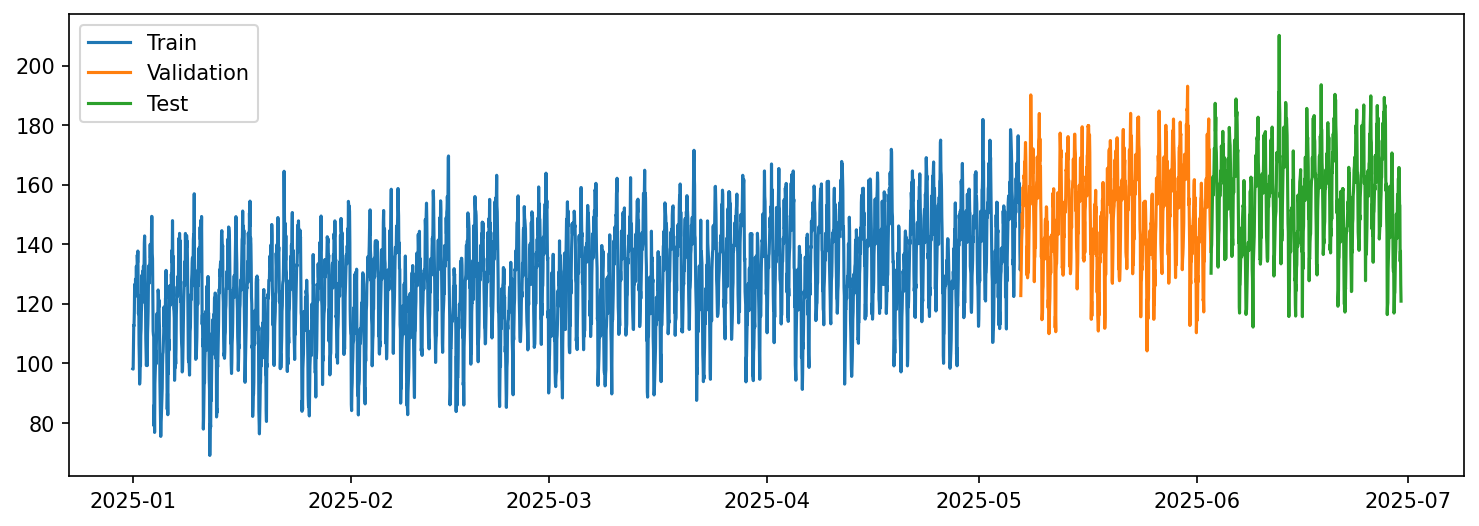

In [12]:
plt.figure(figsize=(12, 4), dpi=150)
plt.plot(train_df['date'], train_df['target'], label='Train')
plt.plot(val_df['date'], val_df['target'], label='Validation')
plt.plot(test_df['date'], test_df['target'], label='Test')
plt.legend()
plt.savefig('artifacts/figures/series_split.png')
plt.show()

# Построение baseline-ов

In [13]:
def add_features(data):
    df_f = data.copy()

    for l in [1, 7, 14]:
        df_f[f'lag_{l}'] = df_f['target'].shift(l)
    
    df_f['rolling_mean_7'] = df_f['target'].shift(1).rolling(7).mean()
    df_f['rolling_std_7'] = df_f['target'].shift(1).rolling(7).std()
    
    df_f['dayofweek'] = df_f['date'].dt.dayofweek
    df_f['hour'] = df_f['date'].dt.hour
    return df_f.dropna()

full_features = add_features(df)
full_features.head()

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,hour
14,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2,14
15,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2,15
16,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2,16
17,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2,17
18,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2,18


In [14]:
results = []

train_feat = full_features[full_features['date'] <= train_df['date'].max()]
val_feat = full_features[(full_features['date'] > train_df['date'].max()) & (full_features['date'] <= val_df['date'].max())]
test_feat = full_features[full_features['date'] > val_df['date'].max()]

scaler = StandardScaler()
X_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek', 'hour']

train_feat_scaled = train_feat.copy()
train_feat_scaled[X_cols] = scaler.fit_transform(train_feat[X_cols])

val_feat_scaled = val_feat.copy()
val_feat_scaled[X_cols] = scaler.transform(val_feat[X_cols])

test_feat_scaled = test_feat.copy()
test_feat_scaled[X_cols] = scaler.transform(test_feat[X_cols])

In [15]:
def get_metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape': mean_absolute_percentage_error(y_true, y_pred)
    }

In [16]:
m1 = get_metrics(val_feat['target'], val_feat['lag_1'])
results.append({'id': 'B1', **m1})

In [17]:
m2 = get_metrics(val_feat['target'], val_feat['rolling_mean_7'])
results.append({'id': 'B2', **m2})

In [18]:
model_b3 = Ridge()
model_b3.fit(train_feat_scaled[X_cols], train_feat_scaled['target'])
y_pred_b3 = model_b3.predict(val_feat_scaled[X_cols])
m3 = get_metrics(val_feat_scaled['target'], y_pred_b3)
results.append({'id': 'B3', **m3})

In [19]:
pd.DataFrame(results)

,id,mae,rmse,mape
0,B1,6.444815,8.201023,0.043979
1,B2,12.702013,15.217645,0.088169
2,B3,6.360191,7.886871,0.042820


# Реализация GRU

In [20]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = data
        self.window_size = window_size
    
    def __len__(self):
        return len(self.data) - self.window_size
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor([y])

In [21]:
window_size = 24  # 24 часа (сутки)
hidden_size = 64
num_layers = 2
learning_rate = 0.001
n_epochs = 50
batch_size = 64

train_target = train_df['target'].values
val_target = val_df['target'].values
test_target = test_df['target'].values

target_scaler = StandardScaler()
train_target_scaled = target_scaler.fit_transform(train_target.reshape(-1, 1)).flatten()
val_target_scaled = target_scaler.transform(val_target.reshape(-1, 1)).flatten()
test_target_scaled = target_scaler.transform(test_target.reshape(-1, 1)).flatten()

train_dataset = TimeSeriesDataset(train_target_scaled, window_size)
val_dataset = TimeSeriesDataset(val_target_scaled, window_size)
test_dataset = TimeSeriesDataset(test_target_scaled, window_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Обучающих примеров: {len(train_dataset)}")
print(f"Валидационных примеров: {len(val_dataset)}")
print(f"Тестовых примеров: {len(test_dataset)}")

Обучающих примеров: 3000
Валидационных примеров: 624
Тестовых примеров: 624


In [22]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [23]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def validate(model, loader, criterion, scaler=None):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item()
            all_preds.extend(output.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
    
    all_preds = np.array(all_preds).flatten()
    all_targets = np.array(all_targets).flatten()
    
    if scaler is not None:
        all_preds_orig = scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
        all_targets_orig = scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()
        return {
            'loss': total_loss / len(loader),
            'mae': mean_absolute_error(all_targets_orig, all_preds_orig),
            'rmse': np.sqrt(mean_squared_error(all_targets_orig, all_preds_orig)),
            'mape': mean_absolute_percentage_error(all_targets_orig, all_preds_orig)
        }
    else:
        return {
            'loss': total_loss / len(loader),
            'mae': mean_absolute_error(all_targets, all_preds),
            'rmse': np.sqrt(mean_squared_error(all_targets, all_preds)),
            'mape': mean_absolute_percentage_error(all_targets, all_preds)
        }

In [24]:
model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [25]:
best_val_mae = float('inf')
train_losses = []
val_losses = []
val_maes = []
val_rmses = []
val_mapes = []

for epoch in range(n_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_metrics = validate(model, val_loader, criterion, scaler=target_scaler)
    
    train_losses.append(train_loss)
    val_losses.append(val_metrics['loss'])
    val_maes.append(val_metrics['mae'])
    val_rmses.append(val_metrics['rmse'])
    val_mapes.append(val_metrics['mape'])
    
    if val_metrics['mae'] < best_val_mae:
        best_val_mae = val_metrics['mae']
        best_val_rmse = val_metrics['rmse']
        best_val_mape = val_metrics['mape']
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')
        best_epoch = epoch + 1
    
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1:3d}/{n_epochs} | train_loss: {train_loss:.4f} | val_MAE: {val_metrics['mae']:.4f} | val_MAPE: {val_metrics['mape']:.4%}")

epoch  10/50 | train_loss: 0.1443 | val_MAE: 6.1443 | val_MAPE: 4.1191%
epoch  20/50 | train_loss: 0.1008 | val_MAE: 5.5640 | val_MAPE: 3.7422%
epoch  30/50 | train_loss: 0.0961 | val_MAE: 5.3773 | val_MAPE: 3.6341%
epoch  40/50 | train_loss: 0.0936 | val_MAE: 5.3288 | val_MAPE: 3.6064%
epoch  50/50 | train_loss: 0.0917 | val_MAE: 5.2960 | val_MAPE: 3.5846%


In [26]:
print(f"Лучшая модель: эпоха {best_epoch}")
print(f"Лучшая MAE на валидации: {best_val_mae:.4f}")
print(f"Лучшая RMSE на валидации: {best_val_rmse:.4f}")
print(f"Лучшая MAPE на валидации: {best_val_mape:.4f}")
results.append({
    'id': 'R1', 
    'mae': best_val_mae, 
    'rmse': best_val_rmse, 
    'mape': best_val_mape
})

Лучшая модель: эпоха 50
Лучшая MAE на валидации: 5.2960
Лучшая RMSE на валидации: 6.8736
Лучшая MAPE на валидации: 0.0358


In [27]:
val_results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ НА ВАЛИДАЦИИ")
print(val_results_df.to_string(index=False))


РЕЗУЛЬТАТЫ НА ВАЛИДАЦИИ
id       mae      rmse     mape
B1  6.444815  8.201023 0.043979
B2 12.702013 15.217645 0.088169
B3  6.360191  7.886871 0.042820
R1  5.296038  6.873572 0.035846


In [28]:
best_model_id = val_results_df.loc[val_results_df['mae'].idxmin(), 'id']
best_val_mae_score = val_results_df['mae'].min()
best_model_id, best_val_mae_score

('R1', np.float64(5.296037673950195))

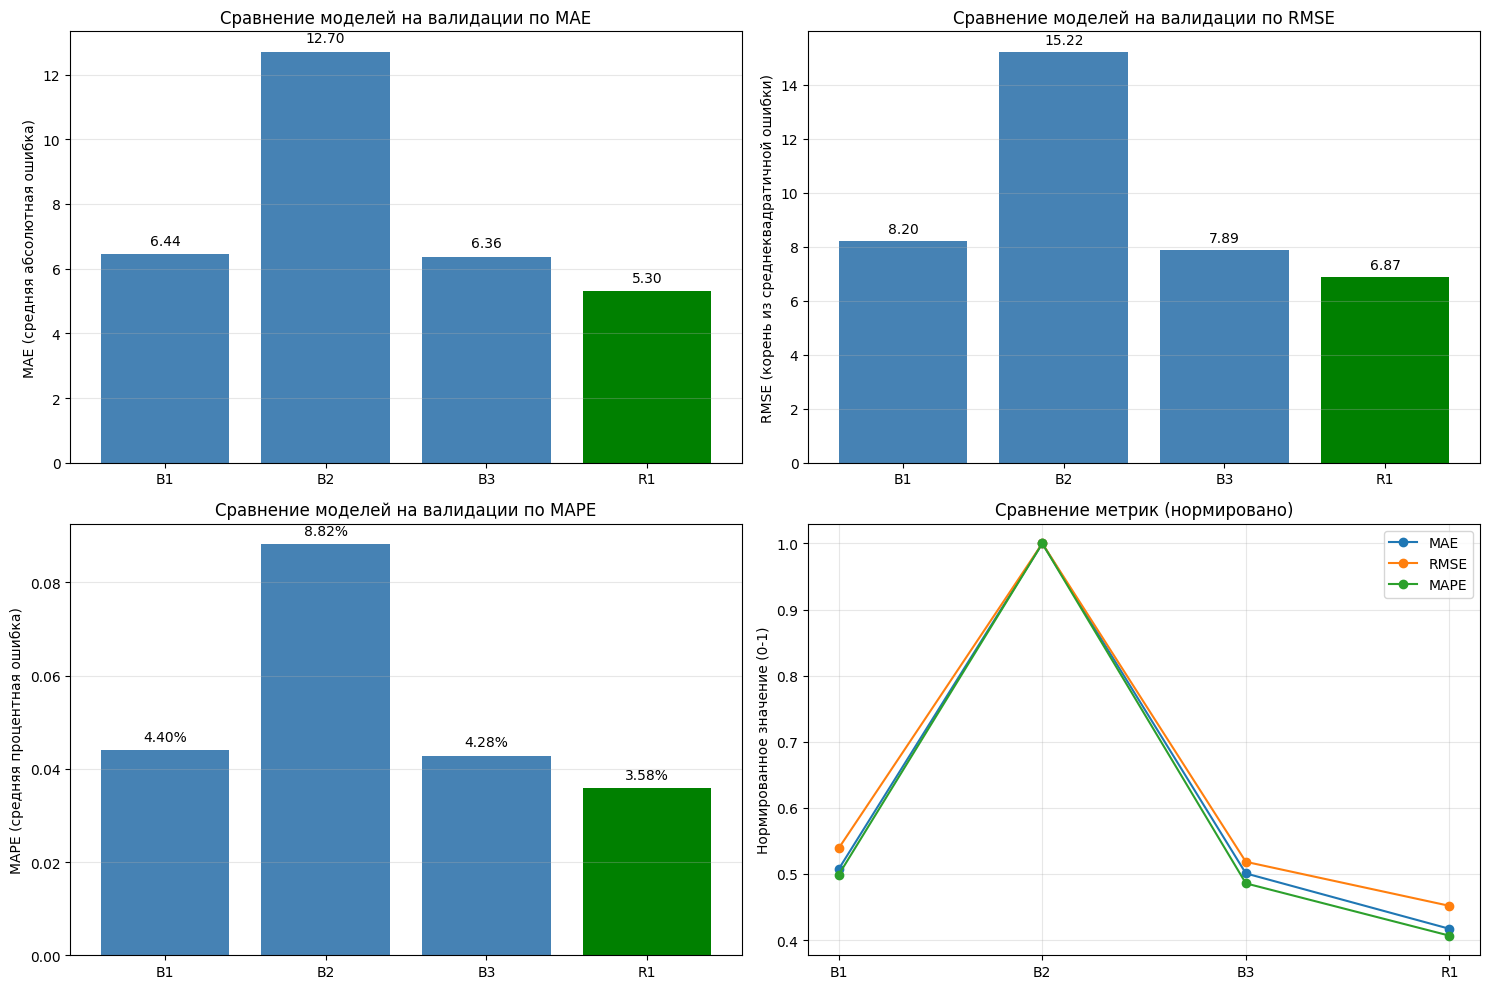

In [29]:
plt.figure(figsize=(15, 10))

# График MAE
plt.subplot(2, 2, 1)
ids = val_results_df['id'].values
maes = val_results_df['mae'].values
colors = ['green' if id == best_model_id else 'steelblue' for id in ids]
plt.bar(ids, maes, color=colors)
plt.ylabel('MAE (средняя абсолютная ошибка)')
plt.title('Сравнение моделей на валидации по MAE')
for i, v in enumerate(maes):
    plt.text(i, v + 0.3, f'{v:.2f}', ha='center')
plt.grid(axis='y', alpha=0.3)

# График RMSE
plt.subplot(2, 2, 2)
rmses = val_results_df['rmse'].values
plt.bar(ids, rmses, color=colors)
plt.ylabel('RMSE (корень из среднеквадратичной ошибки)')
plt.title('Сравнение моделей на валидации по RMSE')
for i, v in enumerate(rmses):
    plt.text(i, v + 0.3, f'{v:.2f}', ha='center')
plt.grid(axis='y', alpha=0.3)

# График MAPE
plt.subplot(2, 2, 3)
mapes = val_results_df['mape'].values
plt.bar(ids, mapes, color=colors)
plt.ylabel('MAPE (средняя процентная ошибка)')
plt.title('Сравнение моделей на валидации по MAPE')
for i, v in enumerate(mapes):
    plt.text(i, v + 0.002, f'{v:.2%}', ha='center')
plt.grid(axis='y', alpha=0.3)

# Общий график всех метрик (нормированный)
plt.subplot(2, 2, 4)
for metric in ['mae', 'rmse', 'mape']:
    values = val_results_df[metric].values
    norm_values = values / values.max()
    plt.plot(ids, norm_values, marker='o', label=metric.upper())
plt.ylabel('Нормированное значение (0-1)')
plt.title('Сравнение метрик (нормировано)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

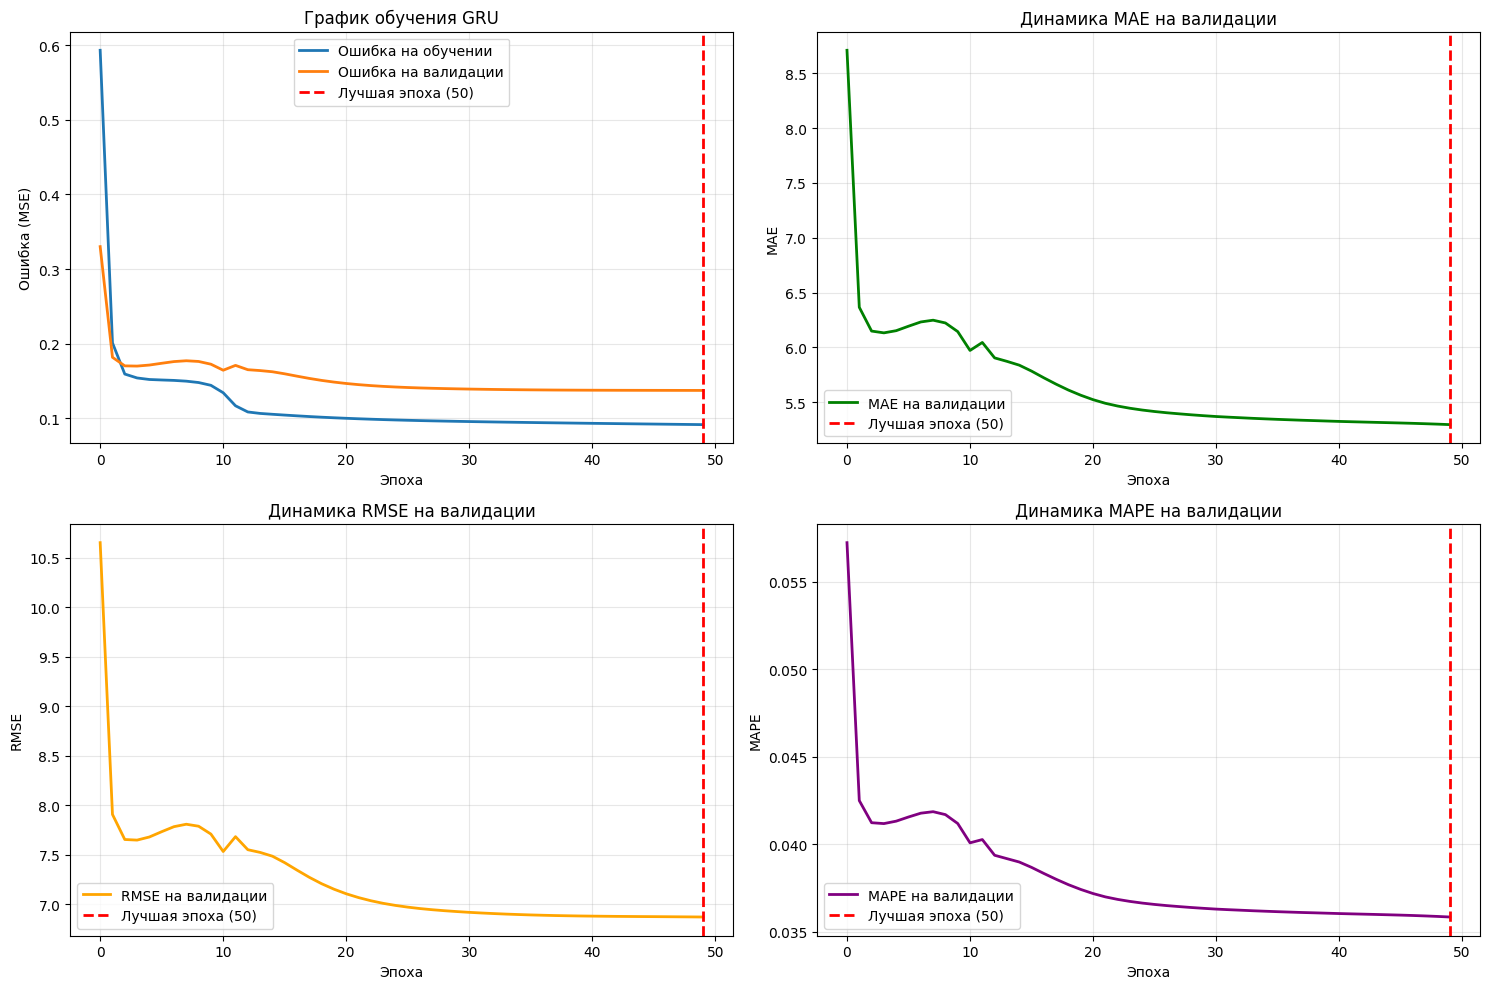

In [30]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Ошибка на обучении', linewidth=2)
plt.plot(val_losses, label='Ошибка на валидации', linewidth=2)
plt.axvline(x=best_epoch-1, color='red', linestyle='--', linewidth=2, label=f'Лучшая эпоха ({best_epoch})')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка (MSE)')
plt.title('График обучения GRU')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(val_maes, label='MAE на валидации', linewidth=2, color='green')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', linewidth=2, label=f'Лучшая эпоха ({best_epoch})')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.title('Динамика MAE на валидации')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(val_rmses, label='RMSE на валидации', linewidth=2, color='orange')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', linewidth=2, label=f'Лучшая эпоха ({best_epoch})')
plt.xlabel('Эпоха')
plt.ylabel('RMSE')
plt.title('Динамика RMSE на валидации')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(val_mapes, label='MAPE на валидации', linewidth=2, color='purple')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', linewidth=2, label=f'Лучшая эпоха ({best_epoch})')
plt.xlabel('Эпоха')
plt.ylabel('MAPE')
plt.title('Динамика MAPE на валидации')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()


Результаты на тесте для GRU:
MAE:  6.4051
RMSE: 8.0670
MAPE: 4.1717%


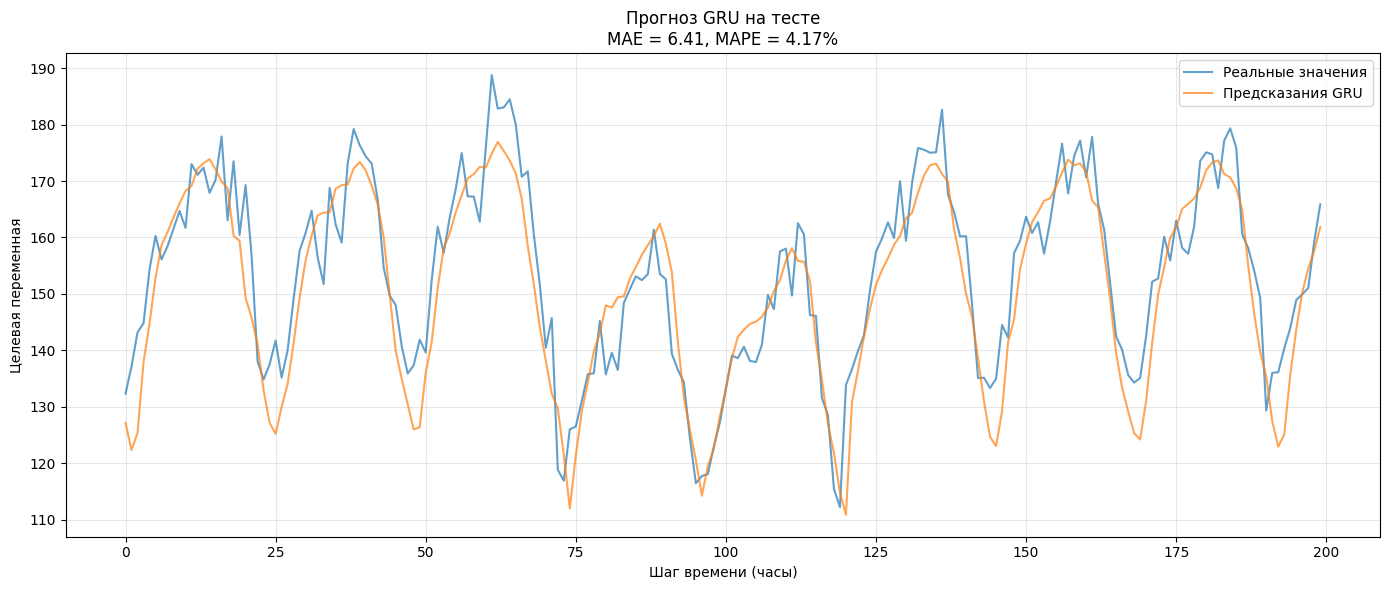

In [31]:
test_metrics = validate(model, test_loader, criterion, scaler=target_scaler)
    
print(f"\nРезультаты на тесте для GRU:")
print(f"MAE:  {test_metrics['mae']:.4f}")
print(f"RMSE: {test_metrics['rmse']:.4f}")
print(f"MAPE: {test_metrics['mape']:.4%}")

model.eval()
all_preds_scaled = []
all_targets_scaled = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = model(x)
        all_preds_scaled.extend(output.cpu().numpy())
        all_targets_scaled.extend(y.numpy())

all_preds_original = target_scaler.inverse_transform(np.array(all_preds_scaled).reshape(-1, 1)).flatten()
all_targets_original = target_scaler.inverse_transform(np.array(all_targets_scaled).reshape(-1, 1)).flatten()

n_points = min(200, len(all_targets_original))
plt.figure(figsize=(14, 6))
plt.plot(all_targets_original[:n_points], label='Реальные значения', alpha=0.7, linewidth=1.5)
plt.plot(all_preds_original[:n_points], label='Предсказания GRU', alpha=0.7, linewidth=1.5)
plt.xlabel('Шаг времени (часы)')
plt.ylabel('Целевая переменная')
plt.legend()
plt.title(f'Прогноз GRU на тесте\nMAE = {test_metrics["mae"]:.2f}, MAPE = {test_metrics["mape"]:.2%}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

In [32]:
config = {
    'model_type': 'GRU',
    'window_size': window_size,
    'hidden_size': hidden_size,
    'num_layers': num_layers,
    'learning_rate': learning_rate,
    'batch_size': batch_size,
    'n_epochs': n_epochs,
    'best_epoch': best_epoch,
    'best_val_mae': float(best_val_mae),
    'best_val_rmse': float(best_val_rmse),
    'best_val_mape': float(best_val_mape),
    'test_mae': float(test_metrics['mae']),
    'test_rmse': float(test_metrics['rmse']),
    'test_mape': float(test_metrics['mape']),
    'seed': RANDOM_SEED,
    'device': str(device)
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)

In [33]:
runs_records = []

for _, row in val_results_df.iterrows():
    record = {
        'experiment_id': row['id'],
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': RANDOM_SEED,
        'split_summary': f'обучение:{len(train_df)}, валидация:{len(val_df)}, тест:{len(test_df)}',
        'window_size': window_size if row['id'] == 'R1' else None,
        'horizon': 1,
        'model_summary': 'Наивный прогноз' if row['id'] == 'B1' 
                        else ('Скользящее среднее' if row['id'] == 'B2'
                              else ('Ridge регрессия' if row['id'] == 'B3'
                                    else f'GRU (окно={window_size})')),
        'features_summary': 'lag_1' if row['id'] == 'B1'
                           else ('rolling_mean_7' if row['id'] == 'B2'
                                 else ('лаги + статистики + календарь' if row['id'] == 'B3'
                                       else 'только target (окна)')),
        'scaler': 'Нет' if row['id'] in ['B1', 'B2'] else 'StandardScaler',
        'optimizer': 'Adam' if row['id'] == 'R1' else None,
        'lr': learning_rate if row['id'] == 'R1' else None,
        'epochs_trained': best_epoch if row['id'] == 'R1' else None,
        'best_val_mae': row['mae'],
        'best_val_rmse': row['rmse'],
        'best_val_mape': row['mape'],
        'test_mae': test_metrics['mae'] if row['id'] == best_model_id else None,
        'test_rmse': test_metrics['rmse'] if row['id'] == best_model_id else None,
        'test_mape': test_metrics['mape'] if row['id'] == best_model_id else None,
        'notes': 'Baseline' if row['id'] in ['B1', 'B2', 'B3'] else 'Лучшая модель'
    }
    runs_records.append(record)

runs_df = pd.DataFrame(runs_records)
runs_df.to_csv('artifacts/runs.csv', index=False)